In [1]:
# Logical operator finder
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import pyvista as pv
import pickle as pkl

# Construction
n, k, d = 8, 3, 2
# Define stabilizers, use 1 for X and -1 for Z, this will make commutation calculations easy
ZZZZIIII = np.array([-1,-1,-1,-1, 0, 0, 0, 0])
IIIIZZZZ = np.array([ 0, 0, 0, 0,-1,-1,-1,-1])
ZZIIZZII = np.array([-1,-1, 0, 0,-1,-1, 0, 0])
IIZZIIZZ = np.array([ 0, 0,-1,-1, 0, 0,-1,-1])
ZIZIZIZI = np.array([-1, 0,-1, 0,-1, 0,-1, 0])
XXXXXXXX = np.array([ 1, 1, 1, 1, 1, 1, 1, 1])
stabilizers = [ZZZZIIII, IIIIZZZZ, ZZIIZZII, ZIZIZIZI, XXXXXXXX]

def commutes(a, b):
    product = 1
    for i in np.multiply(a, b):
        product *= i if i != 0 else 1
    return product == 1

def commutes_all(a):
    for b in stabilizers:
        if not commutes(a, b):
            return False
    return True

def is_stabilizer(a):
    for b in stabilizers:
        for i in range(len(a)):
            if not np.isclose(a[i], b[i]):
                break
        else:
            return True
    return False

def weight(a):
    return np.sum(np.abs(a))

lettersymbols = ['Z', 'I', 'X']
def printall(a):
    for i in a:
        output = ''
        for j in i:
            output += lettersymbols[int(j)+1]
        print(output)

In [2]:
# X candidates
x_candidates = []
for i in range(1, 2**n):
    candidate = np.zeros(n)
    for j in range(n):
        candidate[j] = 1 if i & (1 << j) else 0
    if commutes_all(candidate) and not is_stabilizer(candidate):
        x_candidates.append(candidate)

# Z candidates
z_candidates = []
for i in range(1, 2**n):
    candidate = np.zeros(n)
    for j in range(n):
        candidate[j] = -1 if i & (1 << j) else 0
    if commutes_all(candidate) and not is_stabilizer(candidate):
        z_candidates.append(candidate)

# Candidate pairs
candidate_pairs = []
for x in x_candidates:
    for z in z_candidates:
        if not commutes(x, z):
            candidate_pairs.append((x, z))

print(len(x_candidates), len(z_candidates), len(candidate_pairs))

14 123 896


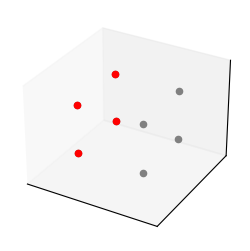

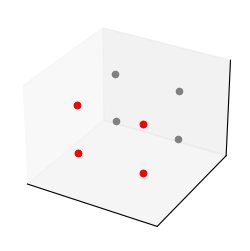

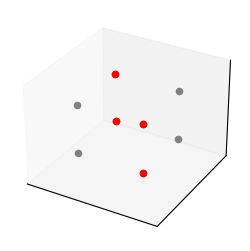

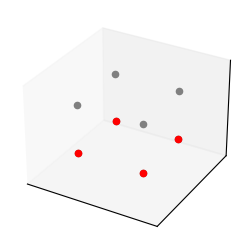

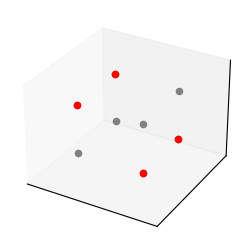

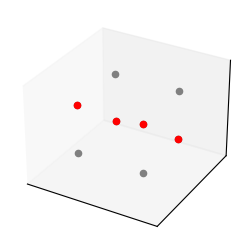

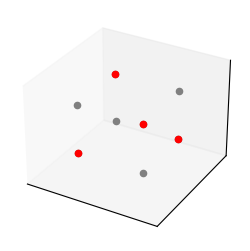

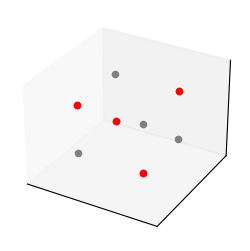

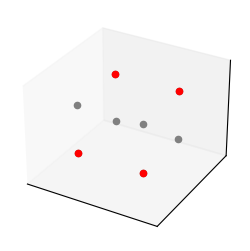

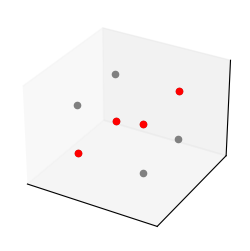

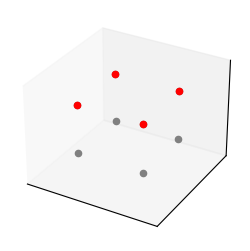

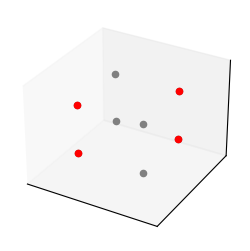

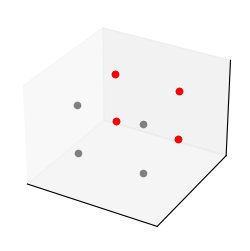

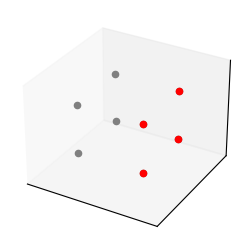

In [3]:
points = [(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1), (1, 0, 0), (1, 0, 1), (1, 1, 0), (1, 1, 1)]
for i in range(len(x_candidates)):
    plt.figure(figsize=(3, 3))
    ax = plt.axes(projection='3d')
    for j in range(len(points)):
        ax.scatter(points[j][0], points[j][1], points[j][2], c='gray', marker='o')
        if x_candidates[i][j] == 1:
            ax.scatter(points[j][0], points[j][1], points[j][2], c='red', marker='o')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_zlim(-0.5, 1.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    plt.show()


In [5]:
with open('x_candidates.pkl', 'wb') as f:
    pkl.dump(x_candidates, f)
with open('z_candidates.pkl', 'wb') as f:
    pkl.dump(z_candidates, f)
with open('candidate_pairs.pkl', 'wb') as f:
    pkl.dump(candidate_pairs, f)


In [2]:
with open('x_candidates.pkl', 'rb') as f:
    x_candidates = pkl.load(f)
print(x_candidates)


[array([1., 1., 1., 1., 0., 0., 0., 0.]), array([1., 1., 0., 0., 1., 1., 0., 0.]), array([0., 0., 1., 1., 1., 1., 0., 0.]), array([1., 0., 1., 0., 1., 0., 1., 0.]), array([0., 1., 0., 1., 1., 0., 1., 0.]), array([0., 1., 1., 0., 0., 1., 1., 0.]), array([1., 0., 0., 1., 0., 1., 1., 0.]), array([0., 1., 1., 0., 1., 0., 0., 1.]), array([1., 0., 0., 1., 1., 0., 0., 1.]), array([1., 0., 1., 0., 0., 1., 0., 1.]), array([0., 1., 0., 1., 0., 1., 0., 1.]), array([1., 1., 0., 0., 0., 0., 1., 1.]), array([0., 0., 1., 1., 0., 0., 1., 1.]), array([0., 0., 0., 0., 1., 1., 1., 1.])]


In [4]:
weights = {}
for z in z_candidates:
    if weight(z) not in weights:
        weights[weight(z)] = 1
    else:
        weights[weight(z)] += 1
print(weights)


{np.float64(2.0): 28, np.float64(4.0): 66, np.float64(6.0): 28, np.float64(8.0): 1}


In [15]:
# Logical operator promotion and auto quotient

def autoQuotient(stabilizers, stabilizer):
    # Check if stabilizer can be simplified
    minweight = weight(stabilizer)
    for i in range(len(stabilizers)):
        if np.sum(stabilizers[i]) < 1: # Check Z type
            quotient = (stabilizers[i] - stabilizer) % 2
            if weight(quotient) < minweight and weight(quotient) > 0:
                minweight = weight(quotient)
                stabilizer = quotient * -1
    # Check if other stabilizers can be simplified
    for i in range(len(stabilizers)):
        if np.sum(stabilizers[i]) < 1: # Check Z type
            quotient = (stabilizers[i] - stabilizer) % 2
            if weight(quotient) < weight(stabilizers[i]) and weight(quotient) > 0:
                stabilizers[i] = quotient * -1
                #print(stabilizers[i])
                autoQuotient(stabilizers, stabilizers[i])
    return stabilizers, stabilizer

def toID(stabilizers):
    bits = np.isclose(np.array(stabilizers), -1).flatten()
    id = 0
    for i in range(len(bits)):
        if bits[i]:
            id += 2**i
    return id


uniqueZgroups = []
uniqueids = []
addedlogicals = []
for zcand in z_candidates:
    newstabilizers = stabilizers.copy()
    newstabilizers, newlogical = autoQuotient(newstabilizers, zcand)
    newstabilizers.append(newlogical)
    newstabilizers = sorted(newstabilizers, key=lambda x: x.tolist() if hasattr(x, "tolist") else list(x))
    #printall(newstabilizers[:-1])
    id = toID(newstabilizers[:-1])
    #print(id)
    if id not in uniqueids:
        uniqueids.append(id)
        uniqueZgroups.append(newstabilizers[:-1])
        addedlogicals.append(newlogical)
print(len(uniqueZgroups), len(uniqueids))

37 37


In [17]:
for i in range(len(uniqueZgroups)):
    zgroup = np.isclose(np.array(uniqueZgroups[i]), -1)
    name = np.isclose(np.array(addedlogicals[i]), -1)
    name = ''.join([str(int(x)) for x in name.flatten()])
    schedule = np.zeros(zgroup.shape, dtype = np.int8)
    for coln in range(len(zgroup[0])):
        for rown in range(len(zgroup)):
            if zgroup[rown, coln]:
                window = 1
                while np.any(schedule[:, coln][:rown] == window) or np.any(schedule[rown][:coln] == window):
                    window += 1
                schedule[rown, coln] = window
    np.save(f"schedules/schedule_{name}.npy", schedule)